# Mount Google Drive and Prepare Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
data_dir = "/content/drive/MyDrive/outdoor_garbage_dataset"

In [3]:
import xml.etree.ElementTree as ET
import pandas as pd

# Load XML
tree = ET.parse(data_dir + "/annotations.xml")
root = tree.getroot()

label_names = [label.find("name").text for label in root.findall("meta/job/labels/label")]
print(label_names)

['is_empty', 'is_full', 'is_scattered']


In [4]:
rows = []
for img in root.findall(".//image"):
    name = img.attrib["name"]
    tags = [tag.attrib["label"] for tag in img.findall("tag")]

    if not tags:
        continue  # skip unlabeled images

    rows.append({
        "image_path": name,
        "is_empty": 1 if "is_empty" in tags else 0,
        "is_full": 1 if "is_full" in tags else 0,
        "is_scattered": 1 if "is_scattered" in tags else 0,
    })


data_info = pd.DataFrame(rows)
data_info["stratify_col"] = data_info[['is_empty', 'is_full', 'is_scattered']].astype(str).agg('-'.join, axis=1)
data_info.head()
data_info.to_csv("data.csv")



In [5]:
# --- Stratified split ---
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    data_info,
    test_size=0.2,
    stratify=data_info["stratify_col"],
    random_state=42
)

train_df = train_df.drop("stratify_col", axis = 1)
train_df.to_csv("train.csv", index=False)

test_df = test_df.drop("stratify_col", axis = 1)
test_df.to_csv("test.csv", index=False)

# Dino v2 Workflow

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Transforms (resize + crop + normalize for DINOv2)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),   # DINOv2 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

## CSVImageDataset class and DataLoader

In [7]:


import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

class CSVImageDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

        # List of label columns in the CSV
        self.label_columns = ["is_empty", "is_full", "is_scattered"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        image = Image.open(data_dir + "/img/" + row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Build multi-hot label vector
        label = torch.tensor(row[self.label_columns].astype(float).values,
                dtype=torch.float32)

        return image, label


In [8]:

train_dataset = CSVImageDataset(
    csv_file="train.csv",
    transform=transform
)

test_dataset = CSVImageDataset(
    csv_file="test.csv",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)



## DinoV2Classifier Model and training

In [9]:
import torch
import torch.nn as nn

class DinoV2Classifier(nn.Module):
    def __init__(self, num_classes=3, backbone_name="dinov2_vits14"):
        super(DinoV2Classifier, self).__init__()

        # Load pretrained DINOv2 backbone
        backbone = torch.hub.load('facebookresearch/dinov2', backbone_name)

        # Freeze backbone
        for param in backbone.parameters():
            param.requires_grad = False

        self.backbone = backbone
        self.classifier = nn.Linear(backbone.embed_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

In [10]:
import torch.optim as optim
import json
from sklearn.metrics import f1_score

# threshold for prediction
THRESHOLD = 0.5

model  = DinoV2Classifier(num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()  # multi-label
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training
for epoch in range(15):  # adjust epochs
    model.train()
    total_loss = 0
    all_labels = []
    all_preds = []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels.float())

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Apply sigmoid + threshold to get predictions
        preds = (torch.sigmoid(outputs) > THRESHOLD).float()

        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())

    # Stack all batches
    all_labels = torch.cat(all_labels, dim=0).numpy()
    all_preds = torch.cat(all_preds, dim=0).numpy()

    # Calculate multi-label metrics
    micro_f1 = f1_score(all_labels, all_preds, average="micro")
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Micro F1: {micro_f1:.4f}, Macro F1: {macro_f1:.4f}")



Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 422MB/s]


Epoch 1, Loss: 0.5915, Micro F1: 0.7241, Macro F1: 0.5830
Epoch 2, Loss: 0.4749, Micro F1: 0.7990, Macro F1: 0.5487
Epoch 3, Loss: 0.4089, Micro F1: 0.8374, Macro F1: 0.7029
Epoch 4, Loss: 0.3765, Micro F1: 0.8368, Macro F1: 0.6353
Epoch 5, Loss: 0.3319, Micro F1: 0.8452, Macro F1: 0.6965
Epoch 6, Loss: 0.3015, Micro F1: 0.8824, Macro F1: 0.7871
Epoch 7, Loss: 0.2796, Micro F1: 0.8889, Macro F1: 0.8103
Epoch 8, Loss: 0.2572, Micro F1: 0.9100, Macro F1: 0.8536
Epoch 9, Loss: 0.2466, Micro F1: 0.8978, Macro F1: 0.8318
Epoch 10, Loss: 0.2340, Micro F1: 0.9034, Macro F1: 0.8383
Epoch 11, Loss: 0.2123, Micro F1: 0.9363, Macro F1: 0.9119
Epoch 12, Loss: 0.2192, Micro F1: 0.9412, Macro F1: 0.9142
Epoch 13, Loss: 0.2058, Micro F1: 0.9289, Macro F1: 0.8982
Epoch 14, Loss: 0.1868, Micro F1: 0.9489, Macro F1: 0.9147
Epoch 15, Loss: 0.1802, Micro F1: 0.9610, Macro F1: 0.9486


## Test the model performance

In [15]:
import torch
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

THRESHOLD = 0.5

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)  # raw logits
        preds = (torch.sigmoid(outputs) > THRESHOLD).float()

        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())

# Stack all batches
all_labels = torch.cat(all_labels, dim=0).numpy()
all_preds = torch.cat(all_preds, dim=0).numpy()

# Multi-label metrics
micro_f1 = f1_score(all_labels, all_preds, average="micro")
macro_f1 = f1_score(all_labels, all_preds, average="macro")
micro_precision = precision_score(all_labels, all_preds, average="micro")
micro_recall = recall_score(all_labels, all_preds, average="micro")

print(f"Test Micro F1: {micro_f1:.4f}, Macro F1: {macro_f1:.4f}")
print(f"Test Precision: {micro_precision:.4f}, Recall: {micro_recall:.4f}")



Test Micro F1: 0.8649, Macro F1: 0.7585
Test Precision: 0.8276, Recall: 0.9057


## Display test result visually

### sample display

pred_labels: ['is_full', 'is_scattered']
true_labels: ['is_full', 'is_scattered']
prob: tensor([[0.0636, 0.9161, 0.8580]], device='cuda:0')


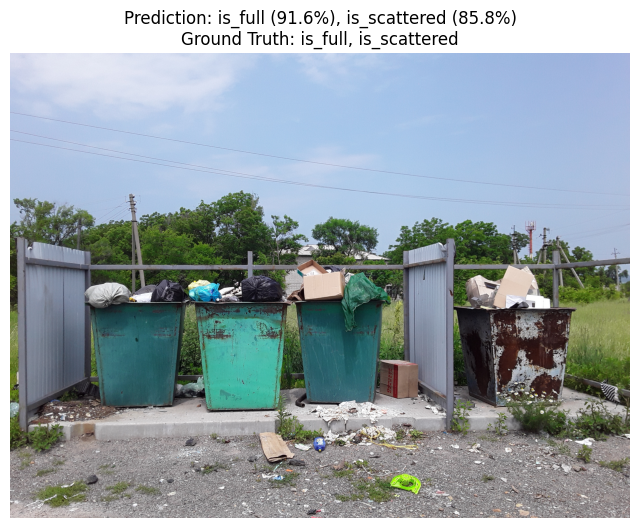

In [40]:
THRESHOLD = 0.5
import matplotlib.pyplot as plt

image_full_name = "/content/drive/MyDrive/outdoor_garbage_dataset/img/51.jpg"
image_open = Image.open(image_full_name)
test_image, labels = test_dataset[7]

img_tensor = test_image.unsqueeze(0)  # shape: [1, C, W, H]
# label columns (multi-label)
label_columns = ["is_empty", "is_full", "is_scattered"]

# map index → label for display
idx_to_class = {i: label for i, label in enumerate(label_columns)}

# Move to device
img_tensor = img_tensor.to(device)

# Predict
model.eval()
THRESHOLD = 0.5

with torch.no_grad():
    output = model(img_tensor)  # raw logits
    pred = (torch.sigmoid(output) > THRESHOLD).float()
    probs = torch.sigmoid(output)

# Get predicted labels and true labels
pred_labels = [idx_to_class[j] for j in range(len(label_columns)) if pred[0][j] == 1]
true_labels = [idx_to_class[j] for j in range(len(label_columns)) if labels[j] == 1]

print("pred_labels:", pred_labels)
print("true_labels:", true_labels)
print("prob:", probs)

# Decide title color
title_color = "black" if set(pred_labels) == set(true_labels) else "red"

# Get confidence for each predicted label
pred_confidences = [probs[0][j].item() for j in range(len(label_columns)) if pred[0, j] == 1]

# Build title string
if pred_labels:
    pred_str = ", ".join([f"{l} ({c*100:.1f}%)" for l, c in zip(pred_labels, pred_confidences)])
else:
    pred_str = "None"

true_str = ", ".join(true_labels) if true_labels else "None"

plt.figure(figsize=(8, 8))  # 6x6 inches
plt.imshow(image_open)
plt.title(f"Prediction: {pred_str}\nGround Truth: {true_str}", fontsize=12, color=title_color)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1)
    return img

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# label columns (multi-label)
label_columns = ["is_empty", "is_full", "is_scattered"]

# map index → label for display
idx_to_class = {i: label for i, label in enumerate(label_columns)}

num_images_to_show = 32
shown = 0

plt.figure(figsize=(12, 18))

THRESHOLD = 0.5  # probability threshold for multi-label prediction

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                  # [B, num_classes]
        probs = torch.sigmoid(outputs)           # probabilities per label
        preds = (probs > THRESHOLD).float()     # multi-label predictions

        for i in range(images.size(0)):
            if shown >= num_images_to_show:
                break

            # Unnormalize & convert image for plotting
            img = unnormalize(images[i])
            img = img.permute(1, 2, 0).cpu().numpy()  # C,H,W → H,W,C

            # Get predicted labels and true labels
            pred_labels = [idx_to_class[j] for j in range(len(label_columns)) if preds[i, j] == 1]
            true_labels = [idx_to_class[j] for j in range(len(label_columns)) if labels[i, j] == 1]

            # Decide title color
            title_color = "black" if set(pred_labels) == set(true_labels) else "red"

            # Get confidence for each predicted label
            pred_confidences = [probs[i, j].item() for j in range(len(label_columns)) if preds[i, j] == 1]

            # Build title string
            if pred_labels:
                pred_str = ", ".join([f"{l} ({c*100:.1f}%)" for l, c in zip(pred_labels, pred_confidences)])
            else:
                pred_str = "None"

            true_str = ", ".join(true_labels) if true_labels else "None"

            plt.subplot(8, 4, shown + 1)
            plt.imshow(img)
            plt.title(f"Pred: {pred_str}\nGT: {true_str}", fontsize=9, color=title_color)
            plt.axis("off")

            shown += 1

        if shown >= num_images_to_show:
            break

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.